In [11]:
"""
portfolio_regime_vs_passive.py
──────────────────────────────
Stratégie de Allocation par Régime Macro vs. Portefeuille Passif
"""

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

sns.set_theme(style="whitegrid")

# ═══════════════════════════════════════════════════════════════════════════
# 1.  CHARGEMENT DES DONNÉES
# ═══════════════════════════════════════════════════════════════════════════

def to_month_end(series):
    return pd.to_datetime(series).dt.to_period('M').dt.to_timestamp('M')

# Commodités
commo = pd.read_excel('Commo_Strategy_Monthly_Returns.xlsx',
                      sheet_name='3_Facteurs').iloc[:, :2]
commo.columns = ['date', 'Commodity']
commo['date']  = to_month_end(commo['date'])

# Devises
curr = pd.read_excel('PPP_Pure_Strategy_Returns_EOM_Net.xlsx',
                     sheet_name='PPP_Pure_Net').iloc[:, :2]
curr.columns = ['date', 'Currency']
curr['date']  = to_month_end(curr['date'])

# Actions — in-sample puis out-of-sample, concaténés sans doublon
eq_is = pd.read_csv('insample_allocation.csv')
eq_is = eq_is[eq_is['strategy'] == 'C_ValueQualityMom'][['date', 'ls_ret']]
eq_is.columns = ['date', 'Equity']
eq_is['date']  = to_month_end(eq_is['date'])

eq_oos = pd.read_csv('master_allocation.csv')
eq_oos = eq_oos[eq_oos['strategy'] == 'C_ValueQualityMom'][['date', 'ls_ret']]
eq_oos.columns = ['date', 'Equity']
eq_oos['date']  = to_month_end(eq_oos['date'])

equity = (pd.concat([eq_is, eq_oos])
            .drop_duplicates('date')
            .sort_values('date'))

# Taux
rates = pd.read_excel('fi_combo_global_quarterly_log_returns.xlsx',
                      sheet_name='Sheet1').iloc[:, :2]
rates.columns = ['date', 'Rate']
rates['date']  = to_month_end(rates['date'])

# Régimes macro
macro = pd.read_csv('macro_regimes.csv').iloc[:, :2]
macro.columns = ['date', 'regime']
macro['date']  = to_month_end(macro['date'])

# Fusion sur la date (inner join → on ne garde que les dates communes)
df = (equity
      .merge(commo,  on='date', how='inner')
      .merge(curr,   on='date', how='inner')
      .merge(rates,  on='date', how='inner')
      .merge(macro,  on='date', how='inner'))

df.set_index('date', inplace=True)
df.sort_index(inplace=True)

# Conversion log-returns → rendements simples pour Commodity, Currency, Rate
for col in ['Commodity', 'Currency', 'Rate']:
    df[col] = np.exp(df[col]) - 1

# Constantes globales
ASSETS         = ['Equity', 'Rate', 'Currency', 'Commodity']
TC_ARRAY       = np.array([0.0050, 0.0010, 0.0010, 0.0020])
REGIMES_SORTED = sorted(df['regime'].unique())

# Séparation IS / OOS — aucune date partagée
df_is  = df.loc[:'2014-12-31'].copy()
df_oos = df.loc['2015-01-31':].copy()

print("─" * 52)
print(f"  Données : {df.index[0].date()} → {df.index[-1].date()}  ({len(df)} mois)")
print(f"  IS      : {df_is.index[0].date()} → {df_is.index[-1].date()}  ({len(df_is)} mois)")
print(f"  OOS     : {df_oos.index[0].date()} → {df_oos.index[-1].date()}  ({len(df_oos)} mois)")
print(f"  Régimes : {REGIMES_SORTED}")
print("─" * 52)

print("\n--- Matrice de corrélation complète (1998–2024) ---")
print(df[ASSETS].corr().round(3))


────────────────────────────────────────────────────
  Données : 1998-01-31 → 2024-10-31  (322 mois)
  IS      : 1998-01-31 → 2014-12-31  (204 mois)
  OOS     : 2015-01-31 → 2024-10-31  (118 mois)
  Régimes : ['crisis', 'goldilocks', 'reflation', 'slowdown', 'stagflation']
────────────────────────────────────────────────────

--- Matrice de corrélation complète (1998–2024) ---
           Equity   Rate  Currency  Commodity
Equity      1.000 -0.063    -0.070     -0.010
Rate       -0.063  1.000    -0.125      0.129
Currency   -0.070 -0.125     1.000     -0.019
Commodity  -0.010  0.129    -0.019      1.000


In [12]:

# ═══════════════════════════════════════════════════════════════════════════
# 2.  CALCUL DES RENDEMENTS NETS  (avec coûts de transaction)
# ═══════════════════════════════════════════════════════════════════════════

def calc_net_returns(weights_flat: np.ndarray,
                     df_subset: pd.DataFrame,
                     init_weights: np.ndarray | None = None
                     ) -> tuple[np.ndarray, np.ndarray]:
    """
    Simule le portefeuille mois par mois.

    Paramètres
    ----------
    weights_flat  : vecteur (n_régimes × n_actifs,) — poids cibles par régime
    df_subset     : DataFrame contenant les colonnes ASSETS + 'regime'
    init_weights  : poids détenus avant le premier mois (pour le calcul du TC)

    Retourne
    --------
    net_ret       : rendements mensuels nets (np.ndarray)
    terminal_w    : poids détenus après le dernier mois (pour chaîner IS → OOS)
    """
    n_r  = len(REGIMES_SORTED)
    n_a  = len(ASSETS)
    w_df = pd.DataFrame(
        weights_flat.reshape(n_r, n_a),
        index=REGIMES_SORTED, columns=ASSETS
    )

    n         = len(df_subset)
    net_ret   = np.zeros(n)
    tgt_mat   = np.array([w_df.loc[r] for r in df_subset['regime']])
    ret_mat   = df_subset[ASSETS].values.astype(float)
    cur_w     = init_weights.copy() if init_weights is not None else tgt_mat[0].copy()

    for i in range(n):
        tw  = tgt_mat[i]
        ret = ret_mat[i]

        # Coût de transaction proportionnel au turnover
        tc       = float(np.sum(np.abs(tw - cur_w) * TC_ARRAY))
        gross_r  = float(np.dot(tw, ret))
        net_ret[i] = gross_r - tc

        # Dérive des poids avec les rendements réalisés
        denom = 1.0 + gross_r
        cur_w = tw * (1.0 + ret) / denom if abs(denom) > 1e-12 else tw.copy()

    return net_ret, cur_w.copy()


# ═══════════════════════════════════════════════════════════════════════════
# 3.  OBJECTIF D'OPTIMISATION  (Sharpe + Rendement)
# ═══════════════════════════════════════════════════════════════════════════

def composite_objective(weights_flat: np.ndarray,
                        df_subset: pd.DataFrame,
                        init_w: np.ndarray | None = None) -> float:
    """
    Minimise −(Sharpe + λ × Rendement annualisé).
    λ = 5 : 1 % de rendement supplémentaire compense 0,05 point de Sharpe.
    """
    net_ret, _ = calc_net_returns(weights_flat, df_subset, init_w)
    std = np.std(net_ret)
    if std < 1e-12:
        return 0.0
    sharpe  = (np.mean(net_ret) / std) * np.sqrt(12)
    ann_ret = (1.0 + np.mean(net_ret)) ** 12 - 1.0
    return -(sharpe + 5.0 * ann_ret)



In [13]:

# ═══════════════════════════════════════════════════════════════════════════
# 4.  OPTIMISATION IN-SAMPLE
# ═══════════════════════════════════════════════════════════════════════════

n_r  = len(REGIMES_SORTED)
n_a  = len(ASSETS)

# Point de départ : égal-pondéré
w0   = np.full(n_r * n_a, 1.0 / n_a)

# Contraintes : chaque ligne (régime) somme à 1
constraints = [
    {'type': 'eq',
     'fun': lambda w, i=i: np.sum(w[i * n_a:(i + 1) * n_a]) - 1.0}
    for i in range(n_r)
]

# Bornes : chaque poids entre 10 % et 50 %
bounds = [(0.10, 0.50)] * (n_r * n_a)

print("\nOptimisation In-Sample en cours …")
df_is_trimmed = df_is.iloc[37:]   # start Feb 2001, same as XGBoost pipeline

res = minimize(
    composite_objective, w0,
    args=(df_is_trimmed,),
    bounds=bounds,
    constraints=constraints,
    method='SLSQP',
    options={'maxiter': 500, 'ftol': 1e-9}
)

opt_weights_df = pd.DataFrame(
    res.x.reshape(n_r, n_a),
    index=REGIMES_SORTED, columns=ASSETS
)

print(f"Convergence : {'✓' if res.success else '✗'}  ({res.message})")
print("\n--- Pondérations optimales par régime ---")
print((opt_weights_df * 100).round(1).to_string() + "  (%)")



Optimisation In-Sample en cours …
Convergence : ✓  (Optimization terminated successfully)

--- Pondérations optimales par régime ---
             Equity  Rate  Currency  Commodity
crisis         10.0  17.8      50.0       22.2
goldilocks     14.5  35.6      39.9       10.0
reflation      14.9  50.0      10.4       24.6
slowdown       15.3  48.8      22.7       13.3
stagflation    50.0  15.1      10.0       24.9  (%)


In [14]:

# ═══════════════════════════════════════════════════════════════════════════
# 5.  SIMULATION  IS et OOS
# ═══════════════════════════════════════════════════════════════════════════

# Poids terminaux IS → initialisation correcte du TC en OOS
passive_flat = np.full(n_r * n_a, 1.0 / n_a)

is_passive_ret, _           = calc_net_returns(passive_flat, df_is)
is_active_ret,  is_term_w   = calc_net_returns(res.x,       df_is)

oos_passive_ret, _ = calc_net_returns(
    passive_flat, df_oos,
    init_weights=np.full(n_a, 0.25)
)
oos_active_ret, _ = calc_net_returns(
    res.x, df_oos,
    init_weights=is_term_w          # ← poids détenus à la fin de l'IS
)

df_is['Passif']  = is_passive_ret
df_is['Actif']   = is_active_ret
df_oos['Passif'] = oos_passive_ret
df_oos['Actif']  = oos_active_ret

# ═══════════════════════════════════════════════════════════════════════════
# 6.  MÉTRIQUES DE PERFORMANCE
# ═══════════════════════════════════════════════════════════════════════════

def get_metrics(returns, label: str = '') -> pd.Series:
    r   = np.asarray(returns, dtype=float)
    ann = (1.0 + r).prod() ** (12.0 / len(r)) - 1.0
    vol = r.std() * np.sqrt(12)
    sr  = ann / vol if vol > 0 else 0.0
    cum = (1.0 + r).cumprod()
    mdd = float(((cum - np.maximum.accumulate(cum)) /
                  np.maximum.accumulate(cum)).min())
    cal  = ann / abs(mdd) if mdd != 0 else 0.0
    p5   = float(np.percentile(r, 5))
    cvar = float(r[r <= p5].mean()) if (r <= p5).any() else p5
    return pd.Series({
        'Rendement annualisé'  : f'{ann:.2%}',
        'Volatilité annualisée': f'{vol:.2%}',
        'Sharpe'               : f'{sr:.2f}',
        'Max Drawdown'         : f'{mdd:.2%}',
        'Calmar'               : f'{cal:.2f}',
        'Skewness'             : f'{stats.skew(r):.2f}',
        'Kurtosis'             : f'{stats.kurtosis(r):.2f}',
        'VaR 95 %'             : f'{p5:.2%}',
        'CVaR 95 %'            : f'{cvar:.2%}',
    }, name=label)

print("\n--- Métriques NETTES — In-Sample (1998–2014) ---")
print(pd.DataFrame({
    'Passif': get_metrics(df_is['Passif'], 'Passif'),
    'Actif' : get_metrics(df_is['Actif'],  'Actif'),
}))

print("\n--- Métriques NETTES — Out-Of-Sample (2015–2024) ---")
print(pd.DataFrame({
    'Passif': get_metrics(df_oos['Passif'], 'Passif'),
    'Actif' : get_metrics(df_oos['Actif'],  'Actif'),
}))

print("\n--- Rendement moyen mensuel NET par régime (OOS) ---")
regime_bdown = df_oos.groupby('regime')[['Passif', 'Actif']].mean()
print((regime_bdown * 100).round(3).to_string() + "  (%)")



--- Métriques NETTES — In-Sample (1998–2014) ---
                       Passif   Actif
Rendement annualisé     5.06%   6.26%
Volatilité annualisée   3.94%   4.91%
Sharpe                   1.28    1.28
Max Drawdown           -6.82%  -8.94%
Calmar                   0.74    0.70
Skewness                 0.10   -0.65
Kurtosis                 1.14    6.75
VaR 95 %               -1.42%  -1.56%
CVaR 95 %              -2.03%  -2.88%

--- Métriques NETTES — Out-Of-Sample (2015–2024) ---
                        Passif   Actif
Rendement annualisé      3.43%   5.48%
Volatilité annualisée    4.21%   4.85%
Sharpe                    0.82    1.13
Max Drawdown           -11.98%  -7.59%
Calmar                    0.29    0.72
Skewness                 -0.55    0.40
Kurtosis                  1.16    0.99
VaR 95 %                -1.89%  -1.59%
CVaR 95 %               -2.72%  -2.54%

--- Rendement moyen mensuel NET par régime (OOS) ---
             Passif  Actif
regime                    
crisis       -0.79

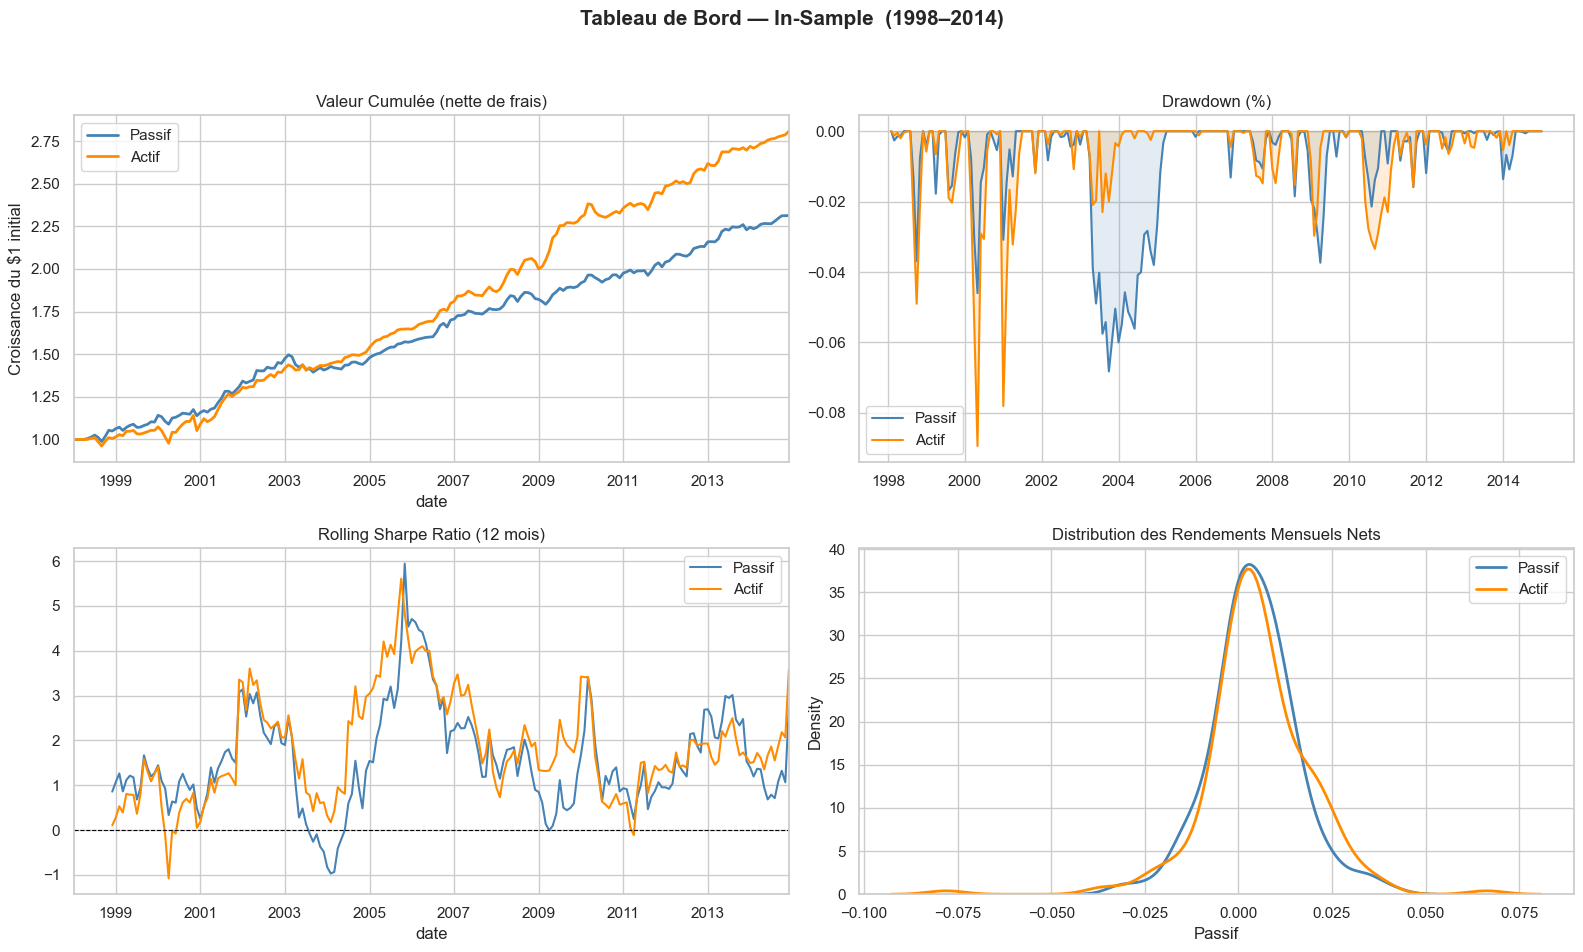

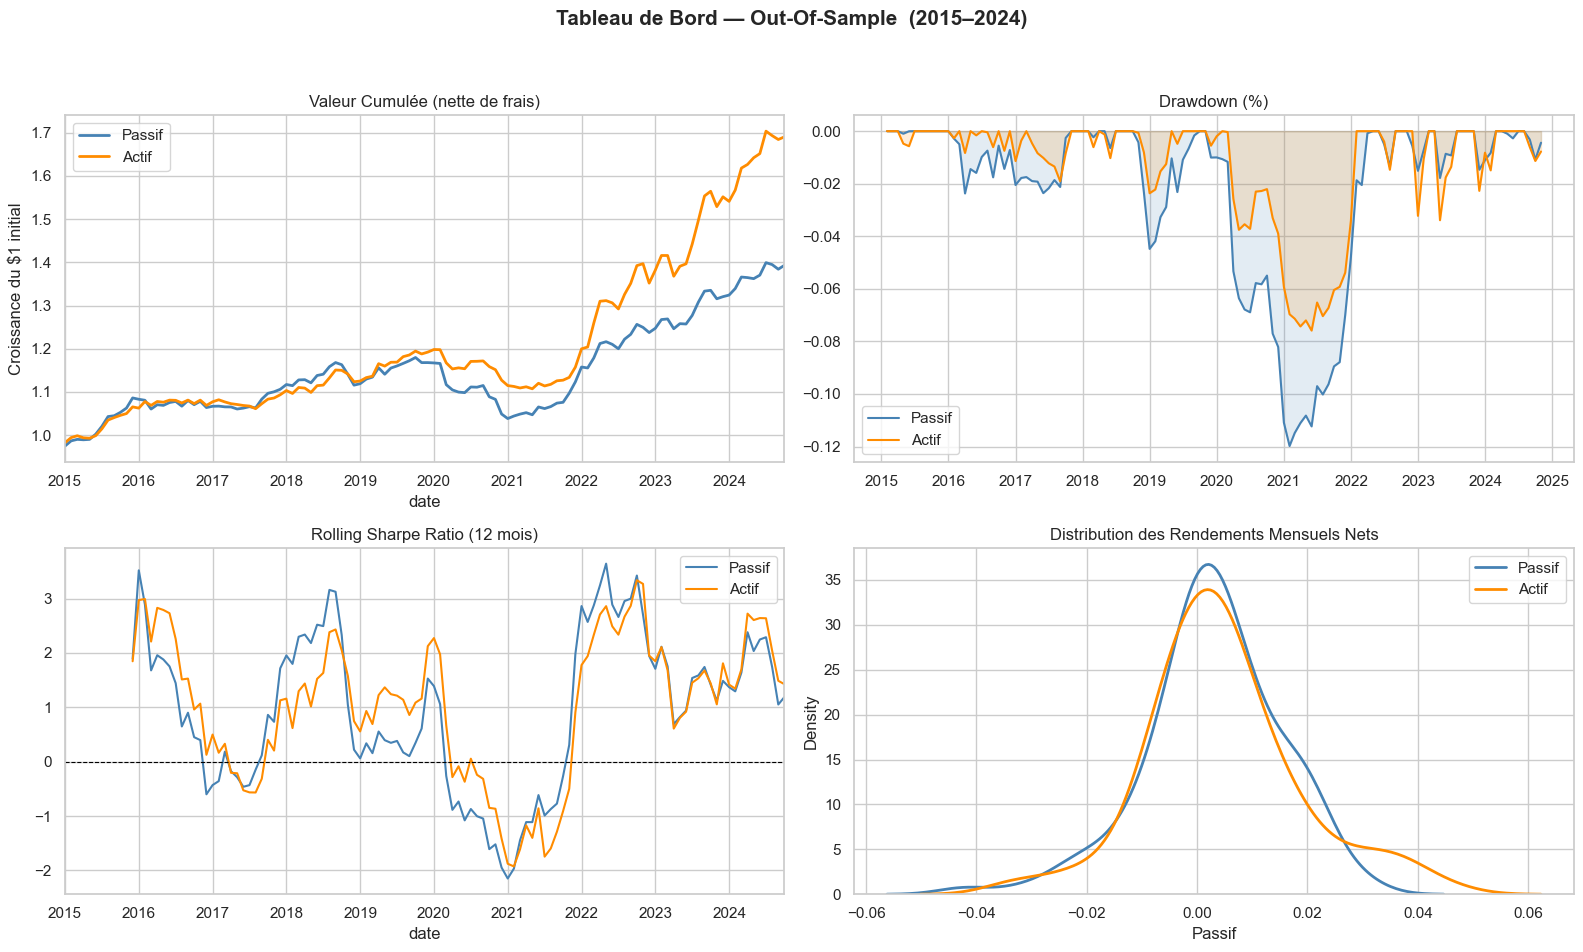

In [15]:

# ═══════════════════════════════════════════════════════════════════════════
# 7.  DASHBOARD
# ═══════════════════════════════════════════════════════════════════════════

def create_dashboard(df_subset: pd.DataFrame, period_name: str):
    colors = {'Passif': 'steelblue', 'Actif': 'darkorange'}
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Tableau de Bord — {period_name}',
                 fontsize=15, fontweight='bold')

    # ── NAV cumulée ───────────────────────────────────────────────────────
    ax = axes[0, 0]
    for col, c in colors.items():
        (1.0 + df_subset[col]).cumprod().plot(ax=ax, label=col,
                                              color=c, linewidth=2)
    ax.set_title('Valeur Cumulée (nette de frais)')
    ax.set_ylabel('Croissance du $1 initial')
    ax.legend()

    # ── Drawdown ──────────────────────────────────────────────────────────
    ax = axes[0, 1]
    for col, c in colors.items():
        cum = (1.0 + df_subset[col]).cumprod()
        dd  = (cum - np.maximum.accumulate(cum)) / np.maximum.accumulate(cum)
        ax.plot(df_subset.index, dd, label=col, color=c, linewidth=1.5)
        ax.fill_between(df_subset.index, 0, dd, alpha=0.15, color=c)
    ax.set_title('Drawdown (%)')
    ax.legend()

    # ── Rolling Sharpe 12 mois ────────────────────────────────────────────
    ax = axes[1, 0]
    for col, c in colors.items():
        r  = df_subset[col]
        rs = (r.rolling(12).mean() * 12) / (r.rolling(12).std() * np.sqrt(12))
        rs.plot(ax=ax, label=col, color=c, linewidth=1.5)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title('Rolling Sharpe Ratio (12 mois)')
    ax.legend()

    # ── Distribution des rendements ───────────────────────────────────────
    ax = axes[1, 1]
    for col, c in colors.items():
        sns.kdeplot(df_subset[col], ax=ax, label=col, color=c, linewidth=2)
    ax.set_title('Distribution des Rendements Mensuels Nets')
    ax.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


create_dashboard(df_is,  "In-Sample  (1998–2014)")
create_dashboard(df_oos, "Out-Of-Sample  (2015–2024)")



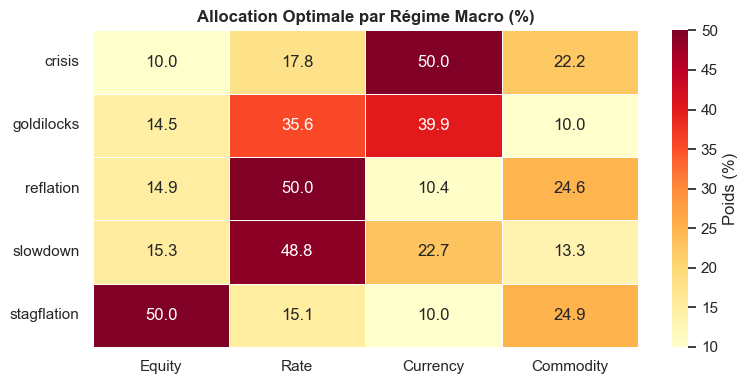

In [16]:

# ═══════════════════════════════════════════════════════════════════════════
# 8.  HEATMAP DES POIDS PAR RÉGIME
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    opt_weights_df * 100,
    annot=True, fmt='.1f',
    cmap='YlOrRd', linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Poids (%)'}
)
ax.set_title('Allocation Optimale par Régime Macro (%)', fontweight='bold')
plt.tight_layout()
plt.show()


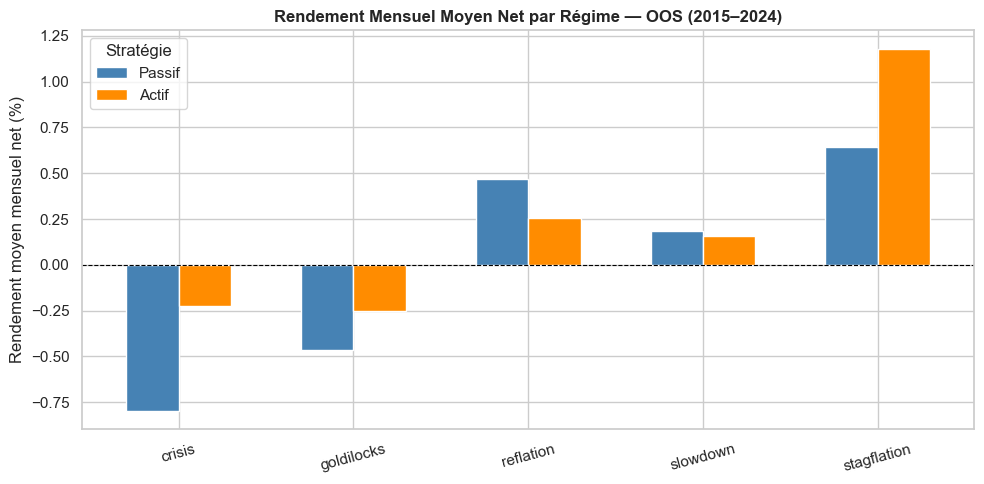

In [17]:


# ═══════════════════════════════════════════════════════════════════════════
# 9.  PERFORMANCE PAR RÉGIME — BARPLOT OOS
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 5))
regime_bdown_plot = df_oos.groupby('regime')[['Passif', 'Actif']].mean() * 100
regime_bdown_plot.plot(kind='bar', ax=ax,
                       color=['steelblue', 'darkorange'],
                       edgecolor='white', width=0.6)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Rendement Mensuel Moyen Net par Régime — OOS (2015–2024)',
             fontweight='bold')
ax.set_ylabel('Rendement moyen mensuel net (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Stratégie')
plt.tight_layout()
plt.show()